# FINETUNING

## Imports

In [6]:
import os
import sys
import re
import urllib.request
import zipfile
import ssl
import torch
import tiktoken
import matplotlib.pyplot as plt
import import_ipynb
import time 
import tqdm
import numpy as np
import pandas as pd
import json
from functools import partial
import psutil
from  pathlib import Path
from matplotlib.ticker import MaxNLocator
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(123)

sys.path.append('../')

In [51]:
import src.downloader as downloader
import src.gpt_model as gpt_model
import src.text_generator as text_generator
import src.metrics as metrics
import src.plots as plots


## Hyperparameters

In [ ]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
    
}

MAX_LENGTH = BASE_CONFIG["context_length"]
STRIDE = BASE_CONFIG["context_length"]
BATCH_SIZE = 8
NUM_EPOCHS = 5
TRAIN_RATIO = 0.7
VALIDATION_RATIO = 0.1
EVAL_FREQ = 50
EVAL_ITER = 5
NUM_WORKERS = 0
NUM_CLASSES = 2

## CLASSIFICATION

### STEP1: DOWNLOADING DATASET

In [ ]:
# Downloading the spam data
# Copy the function from the downloader module
def download_and_unzip_spam_data(url, working_path, zip_name, data_file_name):
    
    # Check if the data file already exists
    if (working_path / data_file_name).exists():
        print(f"{(working_path / data_file_name)} already exists. Skipping download and extraction.")
        return

    # Create the folder if it does not exist
    working_path.mkdir(parents=True, exist_ok=True)

    # Create an unverified SSL context
    ssl_context = ssl._create_unverified_context()

    # Downloading the file
    with urllib.request.urlopen(url, context=ssl_context) as response:
        with open(working_path / zip_name, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(working_path / zip_name, "r") as zip_ref:
        zip_ref.extractall(working_path)

    # Add .tsv file extension
    original_file_path = Path(working_path) / data_file_name[:-4]
    os.rename(original_file_path, Path(working_path) / data_file_name)
    print(f"File downloaded and saved as {Path(working_path) / data_file_name[:-4]}")

# Download and extract the spam data
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
working_path = Path("../data/raw/sms_spam_collection")
zip_name = "sms_spam_collection.zip"
data_file_name = "SMSSpamCollection.tsv"

download_and_unzip_spam_data(url, working_path, zip_name, data_file_name)


../data/raw/sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [12]:
df = pd.read_csv(working_path / data_file_name, sep="\t", header=None, names=["Label", "Text"])
df.head()

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [13]:
def create_balanced_dataset(df):
    
    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [14]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

<div class="alert alert-block alert-info">

This process is similar to converting text into token IDs. 

However, instead of using the GPT
vocabulary, which consists of more than 50,000 words, we are dealing with just two token
IDs: 0 and 1.

</div>

<div class="alert alert-block alert-success">

We create a random_split function to split the dataset into three parts: 70% for
training, 10% for validation, and 20% for testing. 

(These ratios are common in machine
learning to train, adjust, and evaluate models.)    
</div>

In [15]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder


print(len(train_df))
print(len(validation_df))
print(len(test_df))

1045
149
300


In [16]:
train_df.to_csv("../data/processed/sms_spam_collection/train.csv", index=None)
validation_df.to_csv("../data/processed/sms_spam_collection/validation.csv", index=None)
test_df.to_csv("../data/processed/sms_spam_collection/test.csv", index=None)

### STEP 2: CREATING DATALOADERS

<div class="alert alert-block alert-success">

Previously, we utilized a sliding window technique to generate uniformly
sized text chunks, which were then grouped into batches for more efficient model training.
Each chunk functioned as an individual training instance

In the case of email spam classification, have two primary options:

(1) Truncate all messages to the length of the shortest message in the
dataset or batch.

(2) Pad all messages to the length of the longest message in the dataset or
batch.
    
</div>

<div class="alert alert-block alert-warning">

Option 1 is computationally cheaper, but it may result in significant information loss if
shorter messages are much smaller than the average or longest messages, potentially
reducing model performance. 

So, we opt for the second option, which preserves the entire
content of all messages.

To implement option 2, where all messages are padded to the length of the longest
message in the dataset, we add padding tokens to all shorter messages. 

For this purpose,
we use "<|endoftext|>" as a padding token, as discussed in chapter 2.

    
However, instead of appending the string "<|endoftext|>" to each of the text messages
directly, we can add the token ID corresponding to "<|endoftext|>" to the encoded text
</div>

<div class="alert alert-block alert-success">

As we have seen earlier, we first need to implement a PyTorch Dataset, which
specifies how the data is loaded and processed, before we can instantiate the data loaders.
    
</div>

<div class="alert alert-block alert-success">

For this purpose, we define the SpamDataset class.

This SpamDataset class handles several key tasks: it identifies the
longest sequence in the training dataset, encodes the text messages, and ensures that all
other sequences are padded with a padding token to match the length of the longest
sequence.
    
</div>

In [17]:
train_df = pd.read_csv("../data/processed/sms_spam_collection/train.csv")
validation_df = pd.read_csv("../data/processed/sms_spam_collection/validation.csv")
test_df = pd.read_csv("../data/processed/sms_spam_collection/test.csv")

In [18]:
class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [20]:
tokenizer = tiktoken.get_encoding("gpt2")

train_dataset = SpamDataset(
    csv_file="../data/processed/sms_spam_collection/train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


In [21]:
val_dataset = SpamDataset(
    csv_file="../data/processed/sms_spam_collection/validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="../data/processed/sms_spam_collection/test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

print(test_dataset.max_length)

120


<div class="alert alert-block alert-success">

Using the datasets as inputs, we can instantiate the data loaders similarly to what we did earlier. 

However, in this case, the targets represent class labels rather than the next
tokens in the text. 

For instance, choosing a batch size of 8, each batch will consist of 8
training examples of length 120 and the corresponding class label of each example.
</div>

In [ ]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    drop_last=False,
)

In [23]:
print(train_loader.dataset.max_length)

120


In [24]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape) # Batch size x sequence length
print("Label batch dimensions", target_batch.shape) # 0 or 1 values to indicate spam or ham

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [25]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


### STEP 3: INITIALIZING A MODEL WITH PRETRAINED WEIGHTS

In [ ]:

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [28]:
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")




settings, params = downloader.download_and_load_gpt2(model_size=model_size, models_dir="../models/gpt2")

model = gpt_model.GPTModel(BASE_CONFIG)
downloader.load_weights_into_gpt(model, params)
model.eval();

/Users/captain/Documents/projects/GPT-2_from_scratch/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: ../models/gpt2/124M/checkpoint


/Users/captain/Documents/projects/GPT-2_from_scratch/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: ../models/gpt2/124M/encoder.json


/Users/captain/Documents/projects/GPT-2_from_scratch/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

File already exists and is up-to-date: ../models/gpt2/124M/model.ckpt.index


/Users/captain/Documents/projects/GPT-2_from_scratch/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: ../models/gpt2/124M/model.ckpt.meta


/Users/captain/Documents/projects/GPT-2_from_scratch/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: ../models/gpt2/124M/vocab.bpe


In [30]:
text_1 = "Every effort moves you"
response = text_generator.generate(
    text = text_1,
    model=model,
    tokenizer=tokenizer,
    max_length=15,
    context_size=BASE_CONFIG["context_length"], 
)

print(response)

Every effort moves you forward.

The first step is to understand the importance of your work


In [31]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

response = text_generator.generate(
    text = text_1,
    model=model,
    tokenizer=tokenizer,
    max_length=23,
    context_size=BASE_CONFIG["context_length"], 
)

print(response)

Every effort moves you forward.

The first step is to understand the importance of your work.

The second step is to


<div class="alert alert-block alert-info">

Based on the output, it's apparent that the model struggles with following instructions.

This is anticipated, as it has undergone only pretraining and lacks instruction-finetuning,
which we will explore in the upcoming chapter

The next section prepares the model for classification-finetuning

</div>

### STEP 4: ADDING A CLASSIFICATION HEAD

<div class="alert alert-block alert-success">

In this section, we modify the pretrained large language model to prepare it for
classification-finetuning. 

To do this, we replace the original output layer, which maps the
hidden representation to a vocabulary of 50,257, with a smaller output layer that maps to
two classes: 0 ("not spam") and 1 ("spam"),
    
</div>

<div class="alert alert-block alert-warning">

We could technically use a single output node since we are dealing with a binary
classification task. 

However, this would require modifying the loss function.

Therefore, we choose a
more general approach where the number of output nodes matches the number of
classes. 

For example, for a 3-class problem, such as classifying news articles as
"Technology", "Sports", or "Politics", we would use three output nodes, and so forth.
</div>

<div class="alert alert-block alert-success">

Before we attempt to construct the modified architecture, let's print the model
architecture via print(model), which prints the following:
    
</div>

In [28]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

<div class="alert alert-block alert-success">

Next, we replace the out_head with a new output layer, as illustrated in figure 6.9, that
we will finetune.    
</div>

<div class="alert alert-block alert-success">

To get the model ready for classification-finetuning, we first freeze the model, meaning that
we make all layers non-trainable:

</div>

In [32]:
for param in model.parameters():
    param.requires_grad = False

In [33]:
num_classes = 2
# Add a classification output head --> grad=True
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

In [34]:
#set learnable parameters of last trasnformer block 
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

#set learnable parameters of last norm layer
for param in model.final_norm.parameters():
    param.requires_grad = True

<div class="alert alert-block alert-warning">

Even though we added a new output layer and marked certain layers as trainable or nontrainable, we can still use this model in a similar way to previous chapters. 

For instance, we
can feed it an example text identical to how we have done it in earlier chapters. For
example, consider the following example text:

</div>

In [35]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


<div class="alert alert-block alert-warning">

Remember that we are interested in finetuning this model so that it returns a class label
that indicates whether a model input is spam or not spam. 

To achieve this, we don't need to
finetune all 4 output rows but can focus on a single output token. 

In particular, we will
focus on the last row corresponding to the last output token
</div>

In [36]:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Outputs:
 tensor([[[-1.3073,  1.6859],
         [-7.4484,  5.6707],
         [-6.9117,  5.6700],
         [-4.0556,  4.5710]]])
Outputs dimensions: torch.Size([1, 4, 2])


In [37]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-4.0556,  4.5710]])


### STEP 5: CALCULATING THE CLASSIFICATION LOSS AND ACCURACY

<div class="alert alert-block alert-warning">

In the previous chapter, we computed the token ID of the next token generated by the
LLM by converting the 50,257 outputs into probabilities via the softmax function and then
returning the position of the highest probability via the argmax function. 

In this chapter, we
take the same approach to calculate whether the model outputs a "spam" or "not spam"
prediction for a given input, with the only difference being that we
work with 2-dimensional instead of 50,257-dimensional outputs.
    
</div>

In [38]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
print(probas)
label = torch.argmax(probas)
print("Class label:", label.item())

tensor([[1.7924e-04, 9.9982e-01]])
Class label: 1


<div class="alert alert-block alert-success">
This concept can be used to compute the so-called classification accuracy, which measures
the percentage of correct predictions across a dataset.
</div>

<div class="alert alert-block alert-success">
To determine the classification accuracy, we apply the argmax-based prediction code to
all examples in the dataset and calculate the proportion of correct predictions by defining a
calc_accuracy_loader function:
</div>

In [ ]:
# Calculate the accuracy of the model on the dataset
# Copy of the function from metrics module
def calc_accuracy_loader(data_loader, model, num_batches=None):
    # Set the model to evaluation mode
    training_mode = model.training
    model.eval()

    # Get the device
    device = next(model.parameters()).device

    # Initialize the number of correct predictions and the number of examples
    correct_predictions, num_examples = 0, 0

    # Determine the number of batches to evaluate
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    # Iterate over the data loader
    for i, (input_batch, target_batch) in enumerate(data_loader):
        # Calculate accuracy only for the first num_batches
        if i < num_batches:
            # Move the input and target to the device
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                # Inference of the model on the input batch 
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            
            # Get the predicted labels
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            # Count the number of correct predictions
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break

    # Set the model back to its original mode
    model.train(training_mode)

    return correct_predictions / num_examples

<div class="alert alert-block alert-success">
Let's use the function to determine the classification accuracies across various datasets
estimated from 10 batches for efficiency:
</div>

In [41]:
# Check if a GPU is available
if torch.cuda.is_available():
   device = torch.device("cuda")
elif torch.backends.mps.is_available():
   device = torch.device("mps")
else:
   device = torch.device("cpu")
print(f"Running on {device} device.")

# Move the model to the device
model.to(device)

# Calculate the accuracy on the training, validation, and test sets
train_accuracy = calc_accuracy_loader(data_loader=train_loader, model=model, num_batches=10)
val_accuracy = calc_accuracy_loader(data_loader=val_loader, model=model, num_batches=10)
test_accuracy = calc_accuracy_loader(data_loader=test_loader, model=model, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Running on mps device.
Training accuracy: 48.75%
Validation accuracy: 45.00%
Test accuracy: 48.75%


<div class="alert alert-block alert-info">
    
As we can see, the prediction accuracies are near a random prediction, which would be
50% in this case. 

To improve the prediction accuracies, we need to finetune the model.

</div>

<div class="alert alert-block alert-warning">

Classification accuracy is not a differentiable function, so we use cross entropy
loss as a proxy to maximize accuracy. 

This is the same cross entropy loss discussed earlier. 

Accordingly, the calc_loss_batch function remains the same as in earlier, with one
adjustment: we focus on optimizing only the last token, model(input_batch)[:, -1, :],
rather than all tokens, model(input_batch):

</div>

In [46]:
# Copy of the function from metrics module
def calc_loss_batch_last_logits(input_batch, target_batch, model):
    # Set the model to evaluation mode
    training_mode = model.training
    model.eval()

    # Move the input and target to the device
    device = next(model.parameters()).device
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    
    # Forward pass
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
   
    # Calculate the loss
    loss = torch.nn.functional.cross_entropy(logits, target_batch, label_smoothing=0.1)
    
    # Set the model back to its original mode
    model.train(training_mode)

    return loss

In [47]:
# Calculate the loss on the training, validation, and test sets
# Copy the function from the metrics module
def calc_loss_loader(data_loader, model, loss_fn, num_batches=None):
    # Set the model to evaluation mode
    training_mode = model.training
    model.eval()

    # Initialize the total loss
    total_loss = 0.

    # Determine the number of batches to evaluate
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))

    # Iterate over the data loader
    for i, (input_batch, target_batch) in enumerate(data_loader):

        # Calculate loss onnly for the first num_batches
        if i < num_batches:
            # Calculate the loss for the batch using provided function
            loss = loss_fn(input_batch, target_batch, model)

            # Accumulate the loss
            total_loss += loss.item()
        else:
            # Break the loop if the number of batches is reached
            break
    
    # Set the model back to its original mode
    model.train(training_mode)
    
    return total_loss / num_batches

In [48]:
# Disable gradient tracking for efficiency because we are not training, yet
with torch.no_grad():
    train_loss = calc_loss_loader(data_loader=train_loader, model=model, loss_fn=calc_loss_batch_last_logits, num_batches=10)
    val_loss = calc_loss_loader(data_loader=val_loader, model=model, loss_fn=calc_loss_batch_last_logits, num_batches=10)
    test_loss = calc_loss_loader(data_loader=test_loader, model=model, loss_fn=calc_loss_batch_last_logits, num_batches=10)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 6.582
Validation loss: 6.588
Test loss: 6.163


### STEP 6: FINETUNING THE MODEL ON SUPERVISED DATA

<div class="alert alert-block alert-info">
    
Step 1: Set model to training mode

Step 2: Reset loss gradients from previous batch iteration

Step 3: Calculate loss gradients

Step 4: Update model weights using loss gradients

Step 5: New: track examples instead of tokens

Step 6: Optional evaluation step

Step 7: Calculate accuracy after each epoch

</div>

In [50]:
# Copy the function from the metrics module
def evaluate_model(model, train_loader, val_loader, loss_fn, num_batches=None):
    # Set the model to evaluation mode
    training_mode = model.training
    model.eval()


    # Calculate the loss on the training and validation sets
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, loss_fn=loss_fn, num_batches=num_batches)
        val_loss = calc_loss_loader(val_loader, model, loss_fn=loss_fn, num_batches=num_batches)
    
    # Set the model back to its original mode
    model.train(training_mode)

    return train_loss, val_loss

In [55]:
# Training the classifier
def train_classifier(model, train_loader, val_loader, optimizer, num_epochs, eval_freq, eval_iter):

    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:

            # Reset loss gradients from previous batch iteration
            optimizer.zero_grad() 

            # Calculate loss 
            loss = metrics.calc_loss_batch_last_logits(input_batch=input_batch, target_batch=target_batch, model=model)
            
            # Calculate loss gradients
            loss.backward() 

            # Update model weights using loss gradients
            optimizer.step() 

            # New: track examples instead of tokens seen
            examples_seen += input_batch.shape[0] 
            global_step += 1

            ## 130 batches: training, eval_Freq = 50 --> after 50 batches are processed in each epoch, we print train loss and val loss

            # Optional evaluation step
            if global_step % eval_freq == 0:
                # Evaluate the model on the training and validation sets
                train_loss, val_loss = metrics.evaluate_model(model=model, train_loader=train_loader, val_loader=val_loader, loss_fn=metrics.calc_loss_batch_last_logits)
                
                # Append the losses to track the training progress
                train_losses.append(train_loss)
                val_losses.append(val_loss)

                print(f"Ep {epoch+1} (Step {global_step:06d}): Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = metrics.calc_accuracy_loader(data_loader=train_loader, model=model, num_batches=eval_iter)
        val_accuracy = metrics.calc_accuracy_loader(data_loader=val_loader, model=model, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

<div class="alert alert-block alert-success">
With the model and data loaders prepared, we can now proceed to train the model. 

The following code sets up the training process, including initializing the optimizer, setting the
number of epochs, and defining the evaluation frequency and starting context to evaluate
generated LLM responses during training based on the first validation set instruction
(val_data[0]) we looked at earlier:

</div>

In [56]:
start_time = time.time()

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier(
        model=model, train_loader=train_loader, val_loader=val_loader, optimizer=optimizer,num_epochs=NUM_EPOCHS, eval_freq=EVAL_FREQ, eval_iter=EVAL_ITER)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 5.729, Val loss 5.432
Ep 1 (Step 000050): Train loss 0.685, Val loss 0.685
Ep 1 (Step 000100): Train loss 0.641, Val loss 0.637
Training accuracy: 85.00% | Validation accuracy: 77.50%
Ep 2 (Step 000150): Train loss 0.596, Val loss 0.594
Ep 2 (Step 000200): Train loss 0.555, Val loss 0.551
Ep 2 (Step 000250): Train loss 0.497, Val loss 0.486
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 3 (Step 000300): Train loss 0.449, Val loss 0.428
Ep 3 (Step 000350): Train loss 0.363, Val loss 0.331
Training accuracy: 92.50% | Validation accuracy: 97.50%
Ep 4 (Step 000400): Train loss 0.329, Val loss 0.322
Ep 4 (Step 000450): Train loss 0.305, Val loss 0.310
Ep 4 (Step 000500): Train loss 0.283, Val loss 0.258
Training accuracy: 92.50% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.276, Val loss 0.286
Ep 5 (Step 000600): Train loss 0.258, Val loss 0.257
Training accuracy: 97.50% | Validation accuracy: 97.50%
Training completed in 7.18 minu

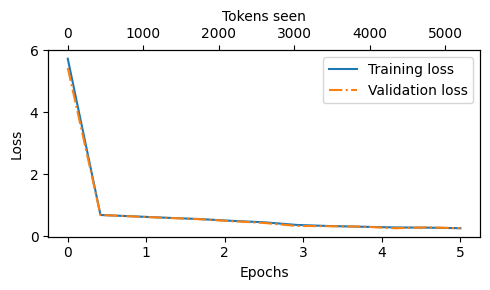

In [ ]:
epochs_tensor = torch.linspace(0, NUM_EPOCHS, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plots.plot_train_val_losses(epochs_seen=epochs_tensor, tokens_seen=examples_seen_tensor, train_losses=train_losses, val_losses=val_losses, labels={"x": "Epochs", "y": "Loss", "train":"Training loss", "validation":"Validation loss", "xlabel":"Exemple seen"}, save_path="../reports/figures/spam_classifier_losses.png")

<div class="alert alert-block alert-info">
    
As we can see based on the sharp downward slope, the model is learning well
from the training data, and there is little to no indication of overfitting; that is, there is no
noticeable gap between the training and validation set losses).

</div>

<div class="alert alert-block alert-success">

Using the same plot_values function, let's now also plot the classification accuracies:

</div>

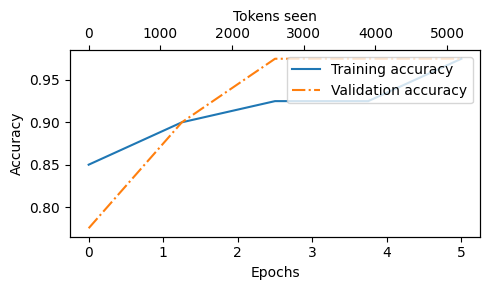

In [75]:
epochs_tensor = torch.linspace(0, NUM_EPOCHS, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plots.plot_train_val_losses(epochs_seen=epochs_tensor, tokens_seen=examples_seen_tensor, train_losses=train_accs, val_losses=val_accs, labels={"x": "Epochs", "y": "Accuracy", "train":"Training accuracy", "validation":"Validation accuracy", "xlabel":"Exemple seen"}, save_path="../reports/figures/spam_classifier_accuracy.png")


<div class="alert alert-block alert-info">
    
Based on the accuracy plot, the model achieves a relatively high training and
validation accuracy after epochs 4 and 5.
    
However, it's important to note that we previously set eval_iter=5 when using the
train_classifier_simple function, which means our estimations of training and
validation performance were based on only 5 batches for efficiency during training.

Now, we will calculate the performance metrics for the training, validation, and test sets
across the entire dataset by running the following code, this time without defining the
eval_iter value:

</div>

In [65]:
train_accuracy = calc_accuracy_loader(data_loader=train_loader, model=model)
val_accuracy = calc_accuracy_loader(data_loader=val_loader, model=model)
test_accuracy = calc_accuracy_loader(data_loader=test_loader, model=model)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.88%
Validation accuracy: 97.32%
Test accuracy: 96.33%


<div class="alert alert-block alert-warning">

The training and test set performances are almost identical.

A slight discrepancy between the training and test set accuracies suggests minimal
overfitting of the training data. 

Typically, the validation set accuracy is somewhat higher
than the test set accuracy because the model development often involves tuning
hyperparameters to perform well on the validation set, which might not generalize as
effectively to the test set.

This situation is common, but the gap could potentially be minimized by adjusting the
model's settings, such as increasing the dropout rate (drop_rate) or the weight_decay
parameter in the optimizer configuration.

</div>

### STEP 7: USING THE LLM AS A SPAM CLASSIFIER

<div class="alert alert-block alert-success">

Finally, let's use the finetuned GPT-based spam classification model. 

The following
classify_review function follows data preprocessing steps similar to those we used in the
SpamDataset implemented earlier in this chapter. 

And then, after processing text into token
IDs, the function uses the model to predict an integer class label, similar to what we have
implemented earlier, and then returns the corresponding class name:
</div>

<div class="alert alert-block alert-info">
    
Step 1: Prepare inputs to the model

Step 2: Truncate sequences if they too long
    
Step 3: Pad sequences to the longest sequence

Step 4: Add batch dimension

Step 5: Model inference without gradient tracking
    
Step 6: Logits of the last output token

Step 7: Return the classified result

</div>

In [66]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]

    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

In [67]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [68]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [69]:
text_3 = ("Bonjour comment tu vas mon ami, est ce que tu es libre ce soir? Je dois te rendre tes $1000 de gains")
print(classify_review(
    text_3, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [71]:
model_path = Path(f"../models/finetuning/spam_classifier_gpt124M.pth")
torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, 
    model_path
)

In [73]:
load_model = torch.load("../models/finetuning/spam_classifier_gpt124M.pth")
model.load_state_dict(load_model["model_state_dict"])

<All keys matched successfully>

## INSTRUCTION FINE-TUNING

### STEP 1: FETCHING DATASET

<div class="alert alert-block alert-success">

In this section, we download and format the instruction dataset for instruction finetuning a
pretrained LLM in this chapter. The dataset consists of 1100 instruction-response pairs.

The following code implements and executes a function to download this dataset, which
is a relatively small file, only 204 KB in size, in JSON format. JSON, or JavaScript Object
Notation, mirrors the structure of Python dictionaries, providing a simple structure for data
interchange that is both human-readable and machine-friendly.

</div>

In [65]:
def download_and_load_file(file_path, url):
    ssl_context = ssl.create_default_context()
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url, context=ssl_context) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


file_path = "../data/raw/finetune_instruction/instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path=file_path, url=url)
print("Number of entries:", len(data))

Number of entries: 1100


In [66]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [67]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


#### CONVERTING INSTRUCTIONS INTO ALPACA FORMAT

<div class="alert alert-block alert-info">

This Alpaca instruction format use this paper [Self-Instruct: Aligning Language Model with Self Generated Instructions](https://arxiv.org/abs/2212.10560)  
This format_input function takes a dictionary entry as input and constructs a formatted
string.
</div>

In [68]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [69]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [70]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


#### SPLITTING DATASET INTO TRAIN-TEST-VALIDATION

In [71]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


### STEP 2: ORGANIZING DATA INTO TRAINING BATCHES

In [72]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            self.encoded_texts.append(
                tokenizer.encode(self._format_alpaca(entry))
            )

    def _format_alpaca(self, entry): 
        instruction_text = (
            f"Below is an instruction that describes a task. "
            f"Write a response that appropriately completes the request."
            f"\n\n### Instruction:\n{entry['instruction']}"
        )

        input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
        response_text = f"\n\n### Response:\n{entry['output']}"
        full_text = instruction_text + input_text + response_text
        return full_text

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

#### PADDING ENDOFTEXT TOKEN IDS FOR TRAINING

In [73]:
# padding token id for GPT-2
def custom_collate_draft_1(batch, pad_token_id=50256, device="cpu"):
    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        # Via padded[:-1], we remove the extra padded token
        # that has been added via the +1 setting in batch_max_length
        # (the extra padding token will be relevant in later codes)
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor


inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


#### CREATING TARGET TOKEN IDS FOR TRAINING

<div class="alert alert-block alert-info">
    
Step 1: Truncate the last token for inputs
                               
Step 2: Shift +1 to the right for targets

</div>

In [74]:
def custom_collate_draft_2(batch, pad_token_id=50256, device="cpu"):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )

        # create input target pairs
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


#### ADDING THE PLACEHOLDER IDS FOR TRAINING

<div class="alert alert-block alert-info">
    
Step 3: Replace all but the first padding tokens in targets by ignore_index

Step 4: Optionally truncate to maximum sequence length

</div>

In [75]:
def custom_collate(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )

        # Create input target pairs
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = custom_collate(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


<div class="alert alert-block alert-info">
    
The 1st tensor represents inputs.
    
The 2nd tensor represents the targets

</div>

#### MASKING TARGET TOKEN IDS

<div class="alert alert-block alert-success">

By masking out the target token IDs that correspond to the instruction, the LLM cross entropy loss is only computed for the generated response target
IDs. 

By masking out the instruction tokens, the model is trained to focus on generating
accurate responses rather than additionally also memorizing instructions, which can help
with reducing overfitting.
</div>

<div class="alert alert-block alert-info">
    
Currently, researchers are divided on whether masking the instructions is universally beneficial during instruction finetuning. 

For instance, a recent
paper titled "Instruction Tuning With Loss Over Instructions" demonstrated that not
masking the instructions benefits the LLM performance.

In this chapter, we do not apply masking and leave it as an optional
exercise for the reader.

</div>

### STEP 3: CREATING DATALOADERS FOR AN INSTRUCTION DATASET

In [77]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# if torch.cuda.is_available():
#    device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#    device = torch.device("mps")
# else:
#    device = torch.device("cpu")

print("Device:", device)

Device: cpu


In [78]:
customized_collate = partial(custom_collate, device=device, allowed_max_length=1024)

In [79]:
num_workers = 0
batch_size = 8



train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [80]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 82]) torch.Size([8, 82])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 88]) torch.Size([8, 88])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 64]) torch.Size([8, 64])
torch.Size([8, 87]) torch.Size([8, 87])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 78]) torch.Size([8, 78])
torch.Size([8, 74]) torch.Size([8, 74])
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 58]) torch.

### STEP 4: LOADING A PRETRAINED LLM

In [81]:

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
model_dir = "../models/gpt2"
settings, params = downloader.download_and_load_gpt2(
    model_size=model_size,
    models_dir=model_dir

)

model = GPT_model.GPTModel(BASE_CONFIG)
downloader.load_weights_into_gpt(model, params)
model.eval();

/Users/captain/Documents/projects/GPT-2_from_scratch/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: ../models/gpt2/355M/checkpoint


/Users/captain/Documents/projects/GPT-2_from_scratch/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: ../models/gpt2/355M/encoder.json


/Users/captain/Documents/projects/GPT-2_from_scratch/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

File already exists and is up-to-date: ../models/gpt2/355M/model.ckpt.index


/Users/captain/Documents/projects/GPT-2_from_scratch/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: ../models/gpt2/355M/model.ckpt.meta


/Users/captain/Documents/projects/GPT-2_from_scratch/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: ../models/gpt2/355M/vocab.bpe


<div class="alert alert-block alert-success">

Before diving into finetuning the model in the next section, let's take a moment to assess
the pretrained LLM's performance on one of the validation tasks by comparing its output to
the expected response. 

This will give us a baseline understanding of how well the model
performs on an instruction-following task right out of the box, prior to finetuning, and will
help us appreciate the impact of finetuning later on. 

We use the first example from the
validation set for this assessment:
</div>

In [82]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [83]:
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [84]:
token_ids = pretraining.generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [85]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


### STEP 5: FINETUNING THE LLM ON INSTRUCTION DATA

#### PREVIOUSLY DEFINED FUNCTIONS WHICH WE WILL REQUIRE

<div class="alert alert-block alert-info">

Step 1: Initialize lists to track losses and tokens seen

Step 2: Start the main training loop

Step 3: Reset loss gradients from previous batch iteration

Step 4: Calculate loss gradients

Step 5: Update model weights using loss gradients

Step 6: Optional evaluation step

Step 7: Print a sample text after each epoch
    
</div>

<div class="alert alert-block alert-info">

The evaluate_model function calculates the loss over the training and
validation set while ensuring the model is in evaluation mode with gradient tracking and
dropout disabled when calculating the loss over the training and validation sets
    
</div>

In [86]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

<div class="alert alert-block alert-info">

The generate_and_print_sample function is a convenience function that we use to track whether the model improves during the training. 

In particular, the generate_and_print_sample function takes a text snippet (start_context) as input,
converts it into token IDs, and feeds it to the LLM to generate a text sample using the
generate_text_simple function we used earlier
    
</div>

In [87]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context

    # Input batch:
    #     tensor([[6109, 3626, 6100,  345],
    #             [6109, 1110, 6622,  257]])
    
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond) ### batch, n_tokens, vocab_size
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [88]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format


In [89]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0: 
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # torch.save(model.state_dict(), f"../models/finetuning/instruction_{epoch}.pth")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


In [90]:
model.to(device)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.8611236572265626
Validation loss: 3.761904001235962


In [91]:
start_time = time.time()

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 5

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.607, Val loss 2.642
Ep 1 (Step 000005): Train loss 1.029, Val loss 1.113
Ep 1 (Step 000010): Train loss 0.828, Val loss 0.956
Ep 1 (Step 000015): Train loss 0.880, Val loss 0.898
Ep 1 (Step 000020): Train loss 0.805, Val loss 0.889
Ep 1 (Step 000025): Train loss 0.813, Val loss 0.847
Ep 1 (Step 000030): Train loss 0.832, Val loss 0.818
Ep 1 (Step 000035): Train loss 0.818, Val loss 0.791
Ep 1 (Step 000040): Train loss 0.688, Val loss 0.776
Ep 1 (Step 000045): Train loss 0.657, Val loss 0.773
Ep 1 (Step 000050): Train loss 0.643, Val loss 0.744
Ep 1 (Step 000055): Train loss 0.709, Val loss 0.732
Ep 1 (Step 000060): Train loss 0.588, Val loss 0.733
Ep 1 (Step 000065): Train loss 0.574, Val loss 0.719
Ep 1 (Step 000070): Train loss 0.608, Val loss 0.714
Ep 1 (Step 000075): Train loss 0.496, Val loss 0.724
Ep 1 (Step 000080): Train loss 0.569, Val loss 0.705
Ep 1 (Step 000085): Train loss 0.500, Val loss 0.693
Ep 1 (Step 000090): Train loss 0.539, Val loss

In [96]:
file_path = "../models/finetuning/"
file_name = f"instruction_finetuning_{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_path + file_name)
print(f"Model saved as {file_name}")

# Load model via
model.load_state_dict(torch.load(file_path + file_name))

Model saved as instruction_finetuning_gpt2-medium355M-sft.pth


<All keys matched successfully>

In [97]:
generate_and_print_sample(model, tokenizer, device, format_input(val_data[0]))

Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive: 'The chef cooks the meal every day.'  ### Response: The chef cooks the meal every day.<|endoftext|>The following is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Convert the active sentence to passive: 'The


In [102]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("../reports/figures/instruction_finetune_loss_plot.pdf")
    plt.show()

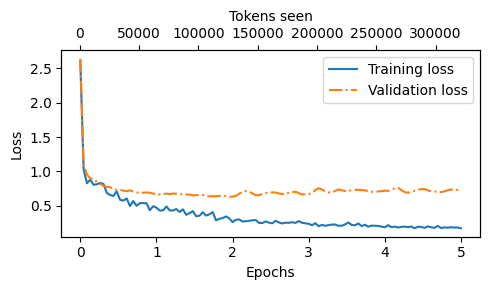

In [103]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

<div class="alert alert-block alert-info">


As we can see in the loss plot shown above, the model's performance on both the
training and validation sets improves substantially over the course of training. 

The rapid
decrease in losses during the initial phase indicates that the model is quickly learning
meaningful patterns and representations from the data. Then, as training progresses to the
second epoch, the losses continue to decrease but at a slower rate, suggesting that the
model is finetuning its learned representations and converging to a stable solution.


While the loss plot in figure 7.17 indicates that the model is training effectively, the most
crucial aspect is its performance in terms of response quality and correctness. In the
remaining sections of this chapter, we will extract the responses and store them in a format
that allows us to evaluate and quantify the response quality.

</div>

### STEP 6: EXTRACTING AND SAVING RESPONSES

In [104]:
for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = pretraining.generate(model=model, idx=text_to_token_ids(input_text, tokenizer).to(device), max_new_tokens=256, context_size=BASE_CONFIG["context_length"],eos_id=50256)
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (generated_text[len(input_text):].replace("### Response:", "").strip())

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> A thunderstorm is a type of cumulus-cirrus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is Jane Aus

In [ ]:
test_data

In [105]:
for entry in test_data[109:]:

    input_text = format_input(entry)

    token_ids = pretraining.generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert 50 miles per hour to kilometers per hour.

Correct response:
>> 50 miles per hour is approximately 80.47 kilometers per hour.

Model response:
>> 50 miles per hour is approximately 32.19 kilometers per hour.
-------------------------------------


<div class="alert alert-block alert-info">


As we can see based on the test set instructions, given responses, and the model's
responses, the model performs relatively well. 

The answers to the first instruction
is clearly correct, while the second answer and the third answers are not correct. 

This is because we have done the fine-tuning for only 5 epochs due to hardware limitations. To get better results, we need to increase the epochs.

</div>

<div class="alert alert-block alert-warning">

Most importantly, we can see that model evaluation is not as straightforward as in the
previous chapter, where we simply calculated the percentage of correct spam/non-spam
class labels to obtain the classification accuracy. 

In practice, instruction-finetuned LLMs
such as chatbots are evaluated via multiple approaches:

1. Short-answer and multiple choice benchmarks such as MMLU ("Measuring
Massive Multitask Language Understanding," https://arxiv.org/abs/2009.
03300), which test the general knowledge of a model.

2. Human preference comparison to other LLMs, such as LMSYS chatbot
arena (https://arena.lmsys.org).

3. Automated conversational benchmarks, where another LLM like GPT-4 is
used to evaluate the responses, such as AlpacaEval (https://tatsulab.github.io/alpaca_eval/).
completes the request.

</div>

<div class="alert alert-block alert-success">

Considering the scale of the task at hand, we will implement an approach similar to
method 3, which involves evaluating the responses automatically using another LLM. 

This
will allow us to efficiently assess the quality of the generated responses without the need
for extensive human involvement, thereby saving time and resources while still obtaining
meaningful performance indicators.
</div>

In [106]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [108]:

for i, entry in tqdm.tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("../data/processed/finetune_instruction/instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

100%|██████████| 110/110 [06:48<00:00,  3.71s/it]


<div class="alert alert-block alert-success">

Finally, we save the model as gpt2-medium355M-sft.pth file to be able to reuse it in future
projects:
</div>

In [ ]:
# file_path = "../models/finetuning/"
# file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
# torch.save(model.state_dict(), file_path + file_name)
# print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load(file_path + file_name))

Model saved as gpt2-medium355M-sft.pth


In [ ]:
# Load model via
# model.load_state_dict(torch.load(file_path + file_name))

### STEP 7: EVALUATING THE FINE-TUNED LLM

#### EVALUATING THE FINE-TUNED LLM OLLAMA


<div class="alert alert-block alert-success">

To implement the evaluation step which involves evaluating test set responses in
an automated fashion, we utilize an existing instruction-finetuned 8 billion parameter Llama
3 model developed by Meta AI. 

This model can be run locally using the open-source Ollama
application (https://ollama.com).
</div>

<div class="alert alert-block alert-warning">

Ollama is an efficient application for running LLMs on a laptop. 

It serves as a wrapper
around the open-source llama.cpp library (https://github.com/ggerganov/llama.cpp), which
implements LLMs in pure C/C++ to maximize efficiency. 

However, note that Ollama is only
a tool for generating text using LLMs (inference) and does not support training or finetuning
LLMs.

</div>

<div class="alert alert-block alert-success">

The following code verifies that the Ollama session is running properly before we use
Ollama to evaluate the test set responses generated in the previous section:</div>

In [109]:

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


<div class="alert alert-block alert-success">

An alternative to the ollama run command for interacting with the model is through its
REST API using Python. 

The following query_model function demonstrates how to use the
API:</div>

In [110]:

def query_model(
    prompt,
    model="llama3",
    url="http://localhost:11434/api/chat"
):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # Settings below are required for deterministic responses
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }


    # Convert the dictionary to a JSON formatted string and encode it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Create a request object, setting the method to POST and adding necessary headers
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")

     
    # Send the request and capture the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # Read and decode the response
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data

In [111]:
model = "llama3.2:latest"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily eat plants and plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and grassy weeds.
2. Hay: High-quality hay, such as timothy hay or alfalfa hay, is a staple in a llama's diet. It provides essential nutrients like fiber, protein, and vitamins.
3. Grains: Llamas may also be fed grains like oats, barley, or corn, but these should not make up more than 10% of their diet.
4. Fruits and vegetables: Fresh fruits and vegetables, such as apples, carrots, and sweet potatoes, can be given to llamas as treats or added to their hay.
5. Browse: Llamas may also eat browse, which includes leaves, twigs, and other vegetation from trees and shrubs.

It's essential to note that llamas have a unique digestive system, with a four-chambered stomach, which allows them to break down and extract nutrients from plant material more efficiently than many other 

<div class="alert alert-block alert-success">

Using the query_model function defined earlier, we can evaluate the responses generated
by our finetuned model with a prompt that prompts the Llama 3 model to rate our
finetuned model's responses on a scale from 0 to 100 based on the given test set response
as reference.
</div>

<div class="alert alert-block alert-success">

First, we apply this approach to the first three examples from the test set that we
examined in a previous section:
</div>

In [112]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt, model))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> To rewrite the sentence using a simile, we need to compare the speed of the car to something else.

Correct output: The car is as fast as lightning.

Score: 100

The model response "The car is as fast as a bullet" is close, but not perfect. A simile should use "like" or "as" to make the comparison, whereas "as fast as a bullet" implies that the car is literally a bullet, which isn't the intended meaning.

A better score for the model response would be around 80-90, as it's close to the correct form but not quite there.

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> A thunderstorm is a type of cumulus-cirrus cloud.

Score:
>> I would rate the model response a 0 out of 100.

The correct answer is "cumulonimbus", which is a specific type of cloud that is characterized by its ta

<div class="alert alert-block alert-info">


Based on the generated responses, we can observe that the Llama 3 model provides
reasonable evaluations and is capable of assigning partial points when a model's answer is
not entirely correct. 
    
</div>

In [113]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm.tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores

In [121]:
scores = generate_model_scores(test_data, "model_response", model="llama3.2:latest")
print("Mean score:", np.mean(scores))

Scoring entries:   9%|▉         | 10/110 [00:06<02:11,  1.32s/it]

Could not convert score: I would score this model response an 80.

The model correctly identifies that 11 and 19 are prime numbers, but incorrectly includes 14 as a prime number (it's actually composite). It also incorrectly includes 20 and 22 in the list of prime numbers, when they should be classified as composite. However, it does get one correct classification out of four, which is a decent start.

A perfect response would have identified all four numbers correctly: Prime numbers: 11, 19
Composite numbers: 14, 20, 22.


Scoring entries:  15%|█▍        | 16/110 [00:08<00:49,  1.91it/s]

Could not convert score: I would classify "wood" as a solid.

 Score: 0


Scoring entries:  16%|█▋        | 18/110 [00:11<01:31,  1.00it/s]

...

Could not convert score: The classification of the sentence 'Please open the door.' is imperative.

Score: 80


Scoring entries:  99%|█████████▉| 109/110 [00:55<00:00,  1.98it/s]

Could not convert score: 60

She never forgets to call.


Scoring entries: 100%|██████████| 110/110 [00:55<00:00,  1.99it/s]

Mean score: 47.623655913978496


In [115]:
def discuss(prompt, model="llama3.2:latest"):
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(prompt, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()
    return response_text


#### EVALUATING THE FINE-TUNED LLM MMLU


<div class="alert alert-block alert-success">

first we need to load the test dataset
</div>

In [116]:
import os

file_path = "data/MMLU/test/"
def list_files_in_directory(directory):
    paths = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            paths.append(os.path.join(root, file))
    return paths

files = list_files_in_directory(file_path)
print(files[:5])


[]


In [119]:
choices = ["A", "B", "C", "D"]


def format_subject(subject):
    l = subject.split("_")
    s = ""
    for entry in l:
        s += " " + entry
    return s


def format_example(df, idx, include_answer=True):
    prompt = df.iloc[idx, 0]
    k = df.shape[1] - 2
    for j in range(k):
        prompt += "\n{}. {}".format(choices[j], df.iloc[idx, j + 1])
    prompt += "\nAnswer:"
    if include_answer:
        prompt += " {}\n\n".format(df.iloc[idx, k + 1])
    return prompt


def gen_prompt(train_df, subject, k=-1, include_answer=True):
    prompt = "The following are multiple choice questions (with answers) about {}.\n\n".format(
        format_subject(subject)
    )
    if k == -1:
        k = train_df.shape[0]
    for i in range(k):
        prompt += format_example(train_df, i, include_answer)
    return prompt


In [120]:
df.loc[0].iat[1]

header = ["Question", "A", "B", "C", "D", "Answer"]
df.columns = header


ValueError: Length mismatch: Expected axis has 2 elements, new values have 6 elements

In [ ]:
df_rows = df.iterrows()
print(ro:=next(df_rows))



(0, Question    For which of these two scenarios does the main...
A                                                Wrong, Wrong
B                                            Wrong, Not wrong
C                                            Not wrong, Wrong
D                                        Not wrong, Not wrong
Answer                                                      A
Name: 0, dtype: object)


In [ ]:
prompt = "The following are multiple choice questions you will need to answer to the best of your ability, using one word response(A, B, C, D).\n\n"

question = "Q: " + ro[1]["Question"] + "\n"
choices = "A: " + ro[1]["A"] + "\n" + "B: " + ro[1]["B"] + "\n" + "C: " + ro[1]["C"] + "\n" + "D: " + ro[1]["C"] + "\n"
expected_answer = "Answer: " + ro[1]["Answer"] + "\n"

prompt += question + choices 

In [ ]:
print(prompt)

The following are multiple choice questions you will need to answer to the best of your ability, using one word response(A, B, C, D).

Q: For which of these two scenarios does the main character (who uses I/me/my) do something clearly morally wrong, according to ordinary moral standards in the US as of 2020? Scenario 1 | I spoke to my mom on the phone during my entire work shift. Scenario 2 | I helped my friend escape prison.
A: Wrong, Wrong
B: Wrong, Not wrong
C: Not wrong, Wrong
D: Not wrong, Wrong



In [ ]:
def MMLU_prompt(df, idx):
    prompt = "The following are multiple choice questions you will need to answer to the best of your ability, using one word response(A, B, C, D).\n\n"
    question = "Q: " + df.loc[idx]["Question"] + "\n"
    choices = "A: " + df.loc[idx]["A"] + "\n" + "B: " + df.loc[idx]["B"] + "\n" + "C: " + df.loc[idx]["C"] + "\n" + "D: " + df.loc[idx]["D"] + "\n"
    expected_answer = "Answer: " + df.loc[idx]["Answer"] + "\n"
    prompt += question + choices
    return prompt, expected_answer

In [ ]:
input_text = MMLU_prompt(df, 0)
print(input_text)
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)
response_text = generated_text[len(input_text):].strip()
print(response_text)

('The following are multiple choice questions you will need to answer to the best of your ability, using one word response(A, B, C, D).\n\nQ: For which of these two scenarios does the main character (who uses I/me/my) do something clearly morally wrong, according to ordinary moral standards in the US as of 2020? Scenario 1 | I spoke to my mom on the phone during my entire work shift. Scenario 2 | I helped my friend escape prison.\nA: Wrong, Wrong\nB: Wrong, Not wrong\nC: Not wrong, Wrong\nD: Not wrong, Not wrong\n', 'Answer: A\n')


TypeError: argument 'text': 'tuple' object cannot be converted to 'PyString'

In [ ]:
from pathlib import Path

folder_path = Path("data/MMLU/test/")
file_path = folder_path / "MMLU_1.csv"

print(file_path.stem)

MMLU_1
